In [24]:
import numpy as np
import matplotlib.pyplot as plt

# down = -1
# up = 1

rows = 10
cols = 10

spins = np.zeros((rows, cols))

for i in range(rows):
    for j in range(cols):
        spins[i, j] = np.random.choice([-1, 1]) #spin down

print(spins)

[[-1.  1. -1.  1. -1.  1.  1. -1. -1.  1.]
 [ 1.  1. -1. -1.  1.  1. -1. -1.  1. -1.]
 [-1.  1. -1.  1.  1. -1.  1.  1.  1.  1.]
 [-1. -1.  1. -1. -1. -1. -1.  1. -1. -1.]
 [-1. -1.  1. -1. -1.  1. -1.  1.  1. -1.]
 [ 1. -1. -1. -1.  1. -1.  1.  1.  1. -1.]
 [-1. -1. -1. -1. -1.  1.  1.  1. -1. -1.]
 [-1. -1. -1. -1. -1. -1. -1. -1.  1.  1.]
 [ 1. -1.  1. -1.  1.  1. -1. -1.  1.  1.]
 [ 1. -1.  1. -1.  1. -1.  1.  1.  1. -1.]]


H = - J summation SiSj - h summation Si

In [25]:
J = 1
def Hamiltonian(spins, rows, J):
    E = 0
    for i in range(rows):
        for j in range(cols):
            S = spins[i, j]
            neighbors = (spins[(i+1) % 10, j] + spins[i, (j+1) % 10] + spins[(i-1) % 10, j] + spins[i, (j-1) % 10])
            E += -J * S * neighbors
    return E/2

In [26]:
energies = []
energies.append(Hamiltonian(spins, rows, J))
print(energies)

[np.float64(12.0)]


In [27]:
T = 2.0
steps = 1000
def metropolis_step(spins, T, rows, J):
    for _ in range (rows*cols):
        i = np.random.randint(0, rows)
        j = np.random.randint(0, rows)

        S = spins[i, j]
        neighbors = (spins[(i+1) % 10, j] + spins[i, (j+1) % 10] + spins[(i-1) % 10, j] + spins[i, (j-1) % 10])

        dE = 2 * J * S * neighbors
        if dE < 0 or np.random.rand() < np.exp(-dE / T):
            spins[i,j] *= -1

In [28]:
energies = []
for _ in range(steps):
    metropolis_step(spins, T, rows, J)
    energies.append(Hamiltonian(spins, rows, J))

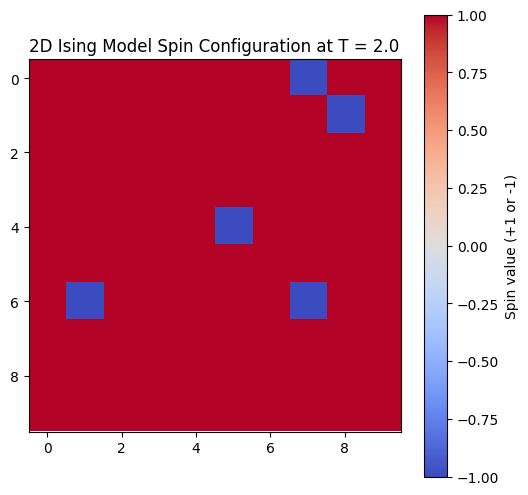

In [29]:
plt.figure(figsize=(6,6))
plt.imshow(spins, cmap='coolwarm', interpolation='nearest')
plt.title(f"2D Ising Model Spin Configuration at T = {T}")
plt.colorbar(label="Spin value (+1 or -1)")
plt.show()

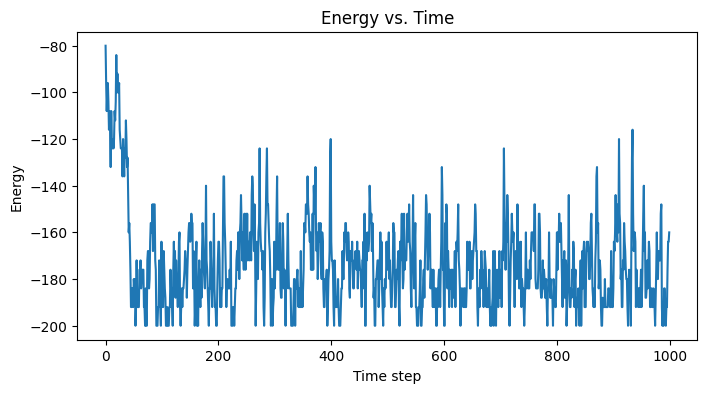

In [30]:
plt.figure(figsize= (8,4))
plt.plot(energies)
plt.xlabel("Time step")
plt.ylabel("Energy")
plt.title("Energy vs. Time")
plt.show()